In [10]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"D:\BackUp_Dec_2025\Predictive_project\A_Z Handwritten Data.csv")

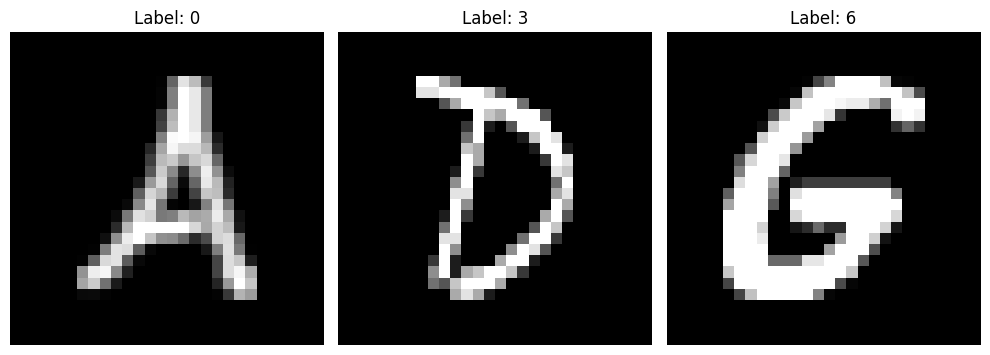

In [6]:
labels = df.iloc[:, 0]
pixels = df.iloc[:, 1:]
indices = [10, 50000, 70789]

plt.figure(figsize=(10, 4))

for j, i in enumerate(indices):
    img = pixels.iloc[i].values.reshape(28, 28)
    
    plt.subplot(1, 3, j+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [15]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


acc_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy (No FE):", acc_nb)


Naive Bayes Accuracy (No FE): 0.561927775540341


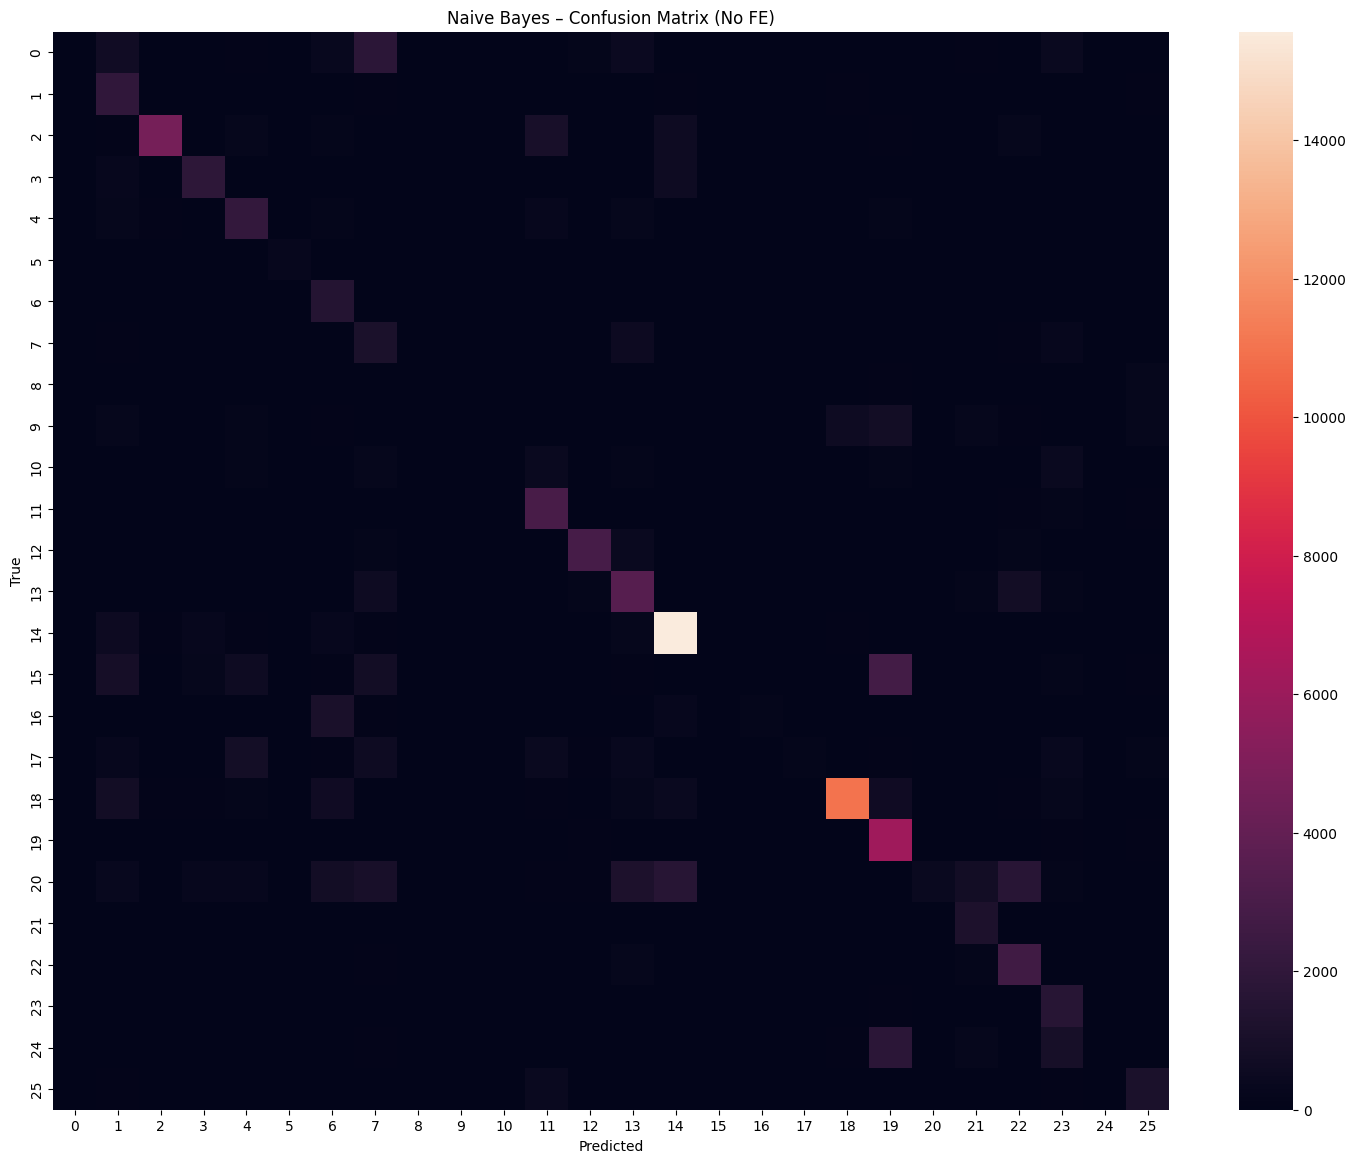

In [12]:
plt.figure(figsize=(18,14))
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=False)
plt.title("Naive Bayes – Confusion Matrix (No FE)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


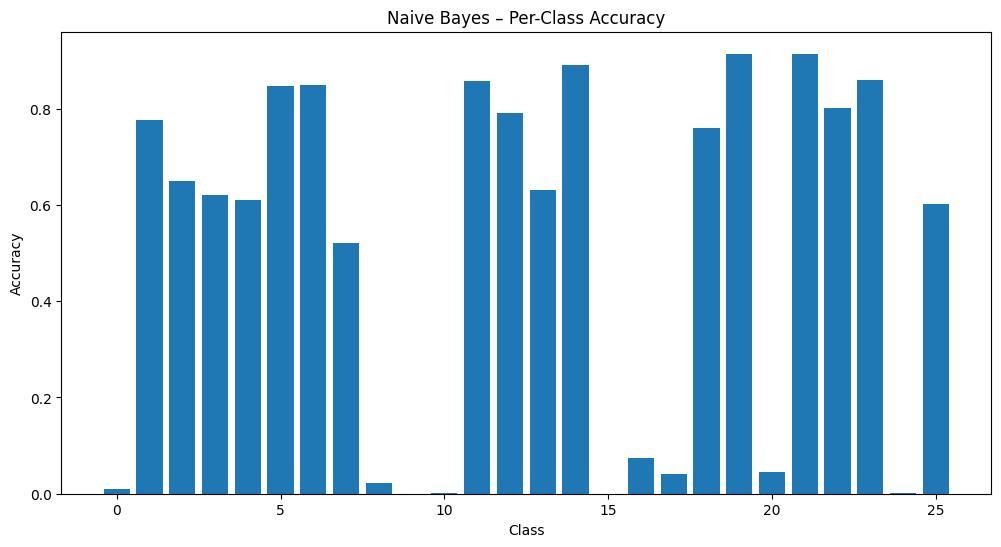

In [13]:
classes = sorted(y_test.unique())
acc_list = []

for c in classes:
    idx = (y_test == c)
    acc_list.append((y_pred_nb[idx] == c).mean())

plt.figure(figsize=(12,6))
plt.bar(classes, acc_list)
plt.title("Naive Bayes – Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler_nb = StandardScaler()
X_train_scaled_nb = scaler_nb.fit_transform(X_train)
X_test_scaled_nb = scaler_nb.transform(X_test)

pca_nb = PCA(n_components=100)
X_train_pca_nb = pca_nb.fit_transform(X_train_scaled_nb)
X_test_pca_nb = pca_nb.transform(X_test_scaled_nb)

nb_fe = GaussianNB()
nb_fe.fit(X_train_pca_nb, y_train)

y_pred_nb_fe = nb_fe.predict(X_test_pca_nb)

acc_nb_fe = accuracy_score(y_test, y_pred_nb_fe)
print("Naive Bayes Accuracy With FE:", acc_nb_fe)

Naive Bayes Accuracy With FE: 0.5999910502528304


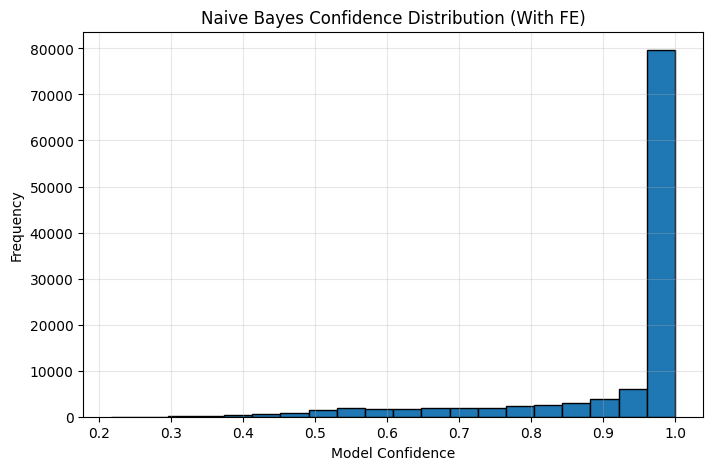

In [17]:
proba_nb_fe = nb_fe.predict_proba(X_test_pca_nb)
conf_nb_fe = proba_nb_fe.max(axis=1)

plt.figure(figsize=(8,5))
plt.hist(conf_nb_fe, bins=20, edgecolor='black')
plt.title("Naive Bayes Confidence Distribution (With FE)")
plt.xlabel("Model Confidence")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


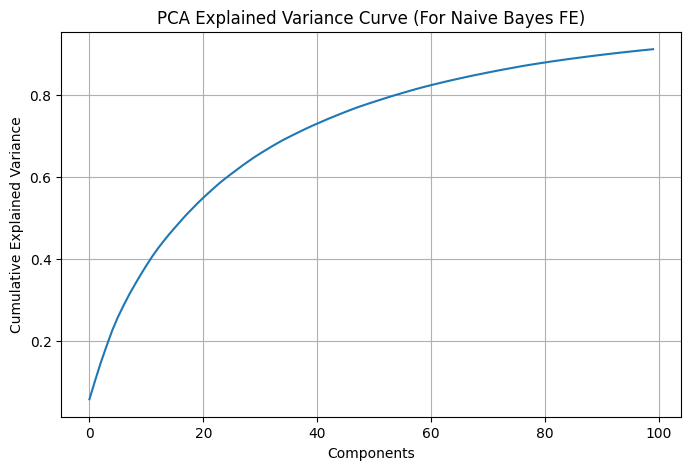

In [18]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_nb.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve (For Naive Bayes FE)")
plt.grid(True)
plt.show()


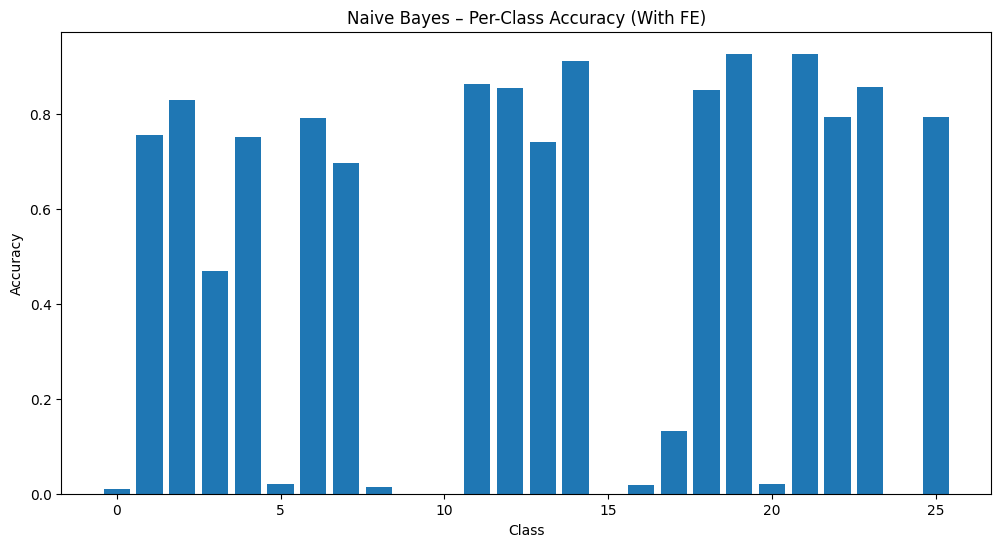

In [19]:
classes = sorted(y_test.unique())
acc_list_fe = []

for c in classes:
    idx = (y_test == c)
    acc_list_fe.append((y_pred_nb_fe[idx] == c).mean())

plt.figure(figsize=(12,6))
plt.bar(classes, acc_list_fe)
plt.title("Naive Bayes – Per-Class Accuracy (With FE)")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()


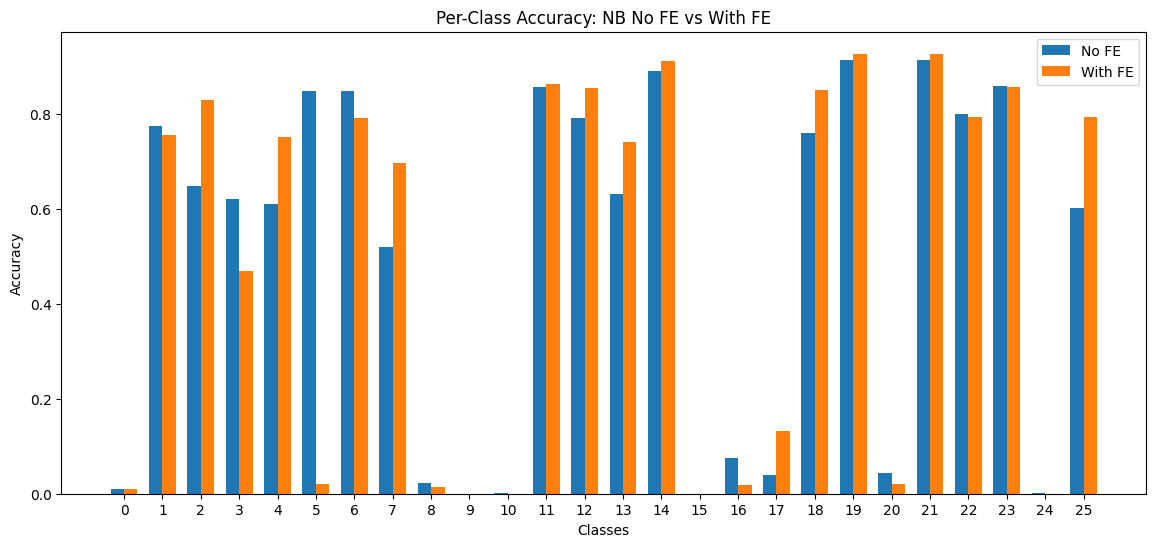

In [21]:
import numpy as np

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(14,6))
plt.bar(x - width/2, acc_list, width, label="No FE")
plt.bar(x + width/2, acc_list_fe, width, label="With FE")
plt.xticks(x, classes)
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy: NB No FE vs With FE")
plt.legend()
plt.show()


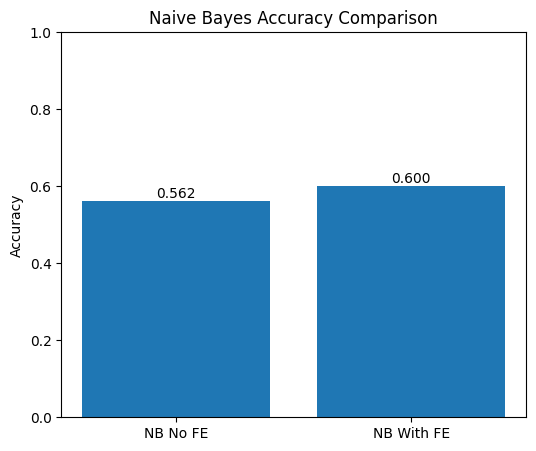

In [24]:
acc_values = [acc_nb, acc_nb_fe]
labels = ["NB No FE", "NB With FE"]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, acc_values)

plt.ylabel("Accuracy")
plt.title("Naive Bayes Accuracy Comparison")
plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.3f}",
             ha='center', va='bottom', fontsize=10)

plt.show()


# Why does Naive Bayes have low accuracy?

Naive Bayes assumes all features are independent.
In images, pixels are not independent. Nearby pixels form shapes and edges. Naive Bayes cannot understand these patterns, so it performs poorly.

Naive Bayes assumes each feature follows a Gaussian distribution.
Pixel values in images are not Gaussian. They are usually between 0 and 255, often skewed or binary. Because the data does not match the assumptions, Naive Bayes gives poor results.

Naive Bayes cannot capture interactions between pixels.
Letters are defined by combinations of strokes, curves, and shapes. Naive Bayes looks at each pixel separately and cannot understand these relationships.

Naive Bayes performs badly in high-dimensional data (784 features in your case).
With so many features, Naive Bayes becomes unstable and very sensitive to noise.

Naive Bayes struggles with multi-class problems.
You have 26 classes (A to Z). Naive Bayes usually works well in simple binary classification, but not with many classes that require complex boundaries.

Naive Bayes is very sensitive to noise and variations in handwriting.
Since handwriting varies a lot, Naive Bayes cannot generalize well.